In [15]:
#Data Analysis lib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

#Models
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import xgboost as xgb

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import metrics

import warnings

warnings.filterwarnings('ignore')

<div>
<font color='grey' size="5px">
1.Load Data
    </font>
</div>

In [16]:
appointment_data = pd.read_csv('/content/healthcare_noshows.csv')

<div>
<font color='grey' size="5px">
2.Data Analysis
    </font>
</div>

Female - Showed Up: 55843
Female - No Show: 14275
Male - Showed Up: 29464
Male - No Show: 7405


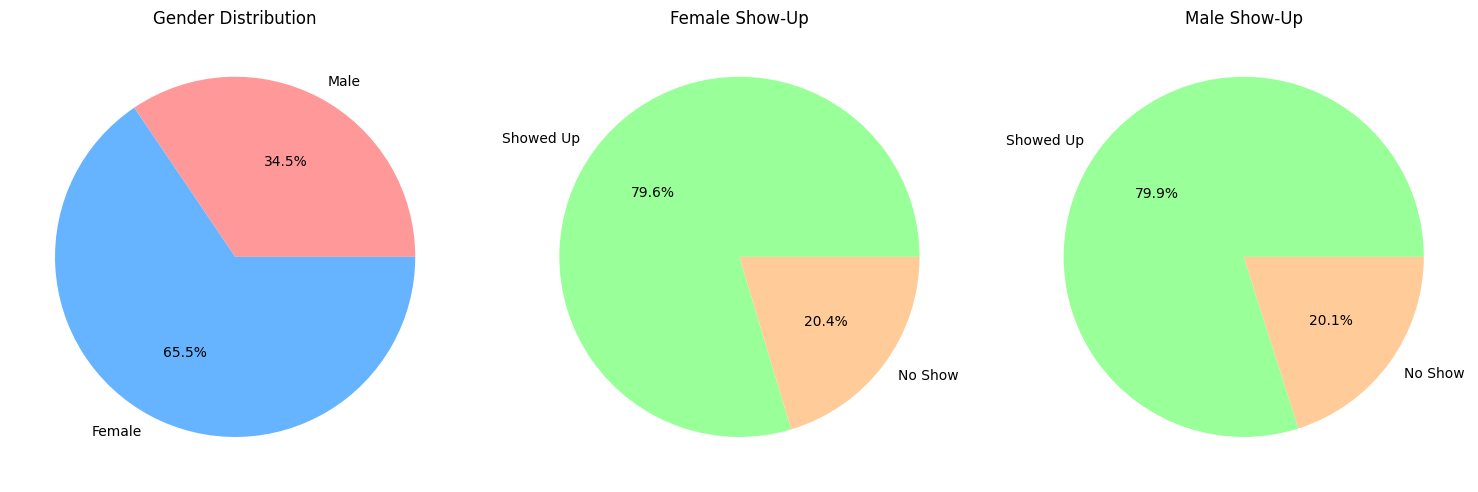

In [17]:
male_count = 0
female_count = 0

for i in range(appointment_data.shape[0]):
    if appointment_data['Gender'][i] == 'M':
        male_count += 1
    else:
        female_count += 1

gender_pie = np.array([male_count, female_count])
gender_labels = ["Male", "Female"]

# Female Data
appointment_female_data = appointment_data[appointment_data['Gender'] == "F"]
female_labels = ["Showed Up", "No Show"]
true_female = len(appointment_female_data[appointment_female_data['Showed_up'] == True])
false_female = len(appointment_female_data[appointment_female_data['Showed_up'] == False])
gender_pie_F = np.array([true_female, false_female])

# Male Data
appointment_male_data = appointment_data[appointment_data['Gender'] == "M"]
male_labels = ["Showed Up", "No Show"]
true_male = len(appointment_male_data[appointment_male_data['Showed_up'] == True])
false_male = len(appointment_male_data[appointment_male_data['Showed_up'] == False])
gender_pie_M = np.array([true_male, false_male])

# Print results
print("Female - Showed Up:", true_female)
print("Female - No Show:", false_female)
print("Male - Showed Up:", true_male)
print("Male - No Show:", false_male)

# Plot pie charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie(gender_pie, labels=gender_labels, colors=['#ff9999','#66b3ff'], autopct='%1.1f%%')
axes[0].set_title('Gender Distribution')

axes[1].pie(gender_pie_F, labels=female_labels, colors=['#99ff99','#ffcc99'], autopct='%1.1f%%')
axes[1].set_title('Female Show-Up')

axes[2].pie(gender_pie_M, labels=male_labels, colors=['#99ff99','#ffcc99'], autopct='%1.1f%%')
axes[2].set_title('Male Show-Up')

plt.tight_layout()
plt.show()


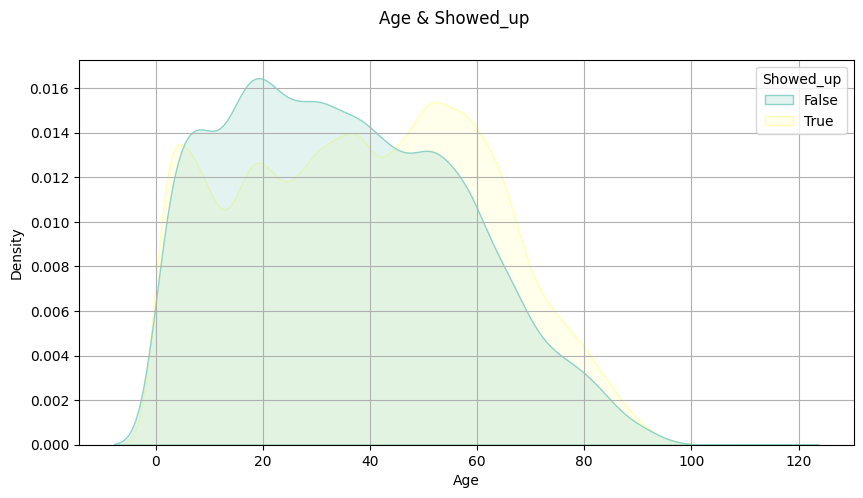

In [18]:
plt.figure(figsize=(10, 5))
plt.suptitle('Age & Showed_up')

sns.kdeplot(data=appointment_data, x='Age', hue='Showed_up', fill=True, palette='Set3', common_norm=False)
plt.xlabel('Age')
plt.ylabel('Density')
plt.grid()
plt.show()


<div>
<font color='grey' size="5px">
3.Data preparation
    </font>
</div>

In [19]:
x = appointment_data.drop(columns=['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 'Neighbourhood', 'Showed_up'])
gender_pie = appointment_data['Showed_up']

print(x.shape)
print(gender_pie.shape)


(106987, 9)
(106987,)


In [20]:
def gender(x):
    if x == 'F':
        return 0
    else:
        return 1

In [21]:
x['Gender'] = x['Gender'].apply(gender)


In [22]:
x_new = SelectKBest(f_classif, k=5).fit_transform(x, gender_pie)

print(x_new.shape)

(106987, 5)


In [23]:
x_train, x_test, gender_pie_train, gender_pie_test = train_test_split(x_new,gender_pie, test_size=0.3)

print(x_train.shape)
print(gender_pie_train.shape)
print(x_test.shape)
print(gender_pie_test.shape)

(74890, 5)
(74890,)
(32097, 5)
(32097,)


In [24]:
scaler_appointment_data = preprocessing.StandardScaler()

x_train = scaler_appointment_data.fit_transform(x_train)

<div>
<font color='grey' size="5px">
4. RF model
    </font>
</div>

In [25]:
RF_model = RandomForestClassifier(random_state=42)

RF_model.fit(x_train, gender_pie_train)

x_test = scaler_appointment_data.fit_transform(x_test)

RF_predict = RF_model.predict(x_test)

In [26]:
# Accuracy
print('Accuracy :', accuracy_score(gender_pie_test, RF_predict))

# Classification report
print(classification_report(gender_pie_test, RF_predict))

Accuracy : 0.7714116584104433
              precision    recall  f1-score   support

       False       0.36      0.18      0.24      6412
        True       0.82      0.92      0.87     25685

    accuracy                           0.77     32097
   macro avg       0.59      0.55      0.55     32097
weighted avg       0.73      0.77      0.74     32097



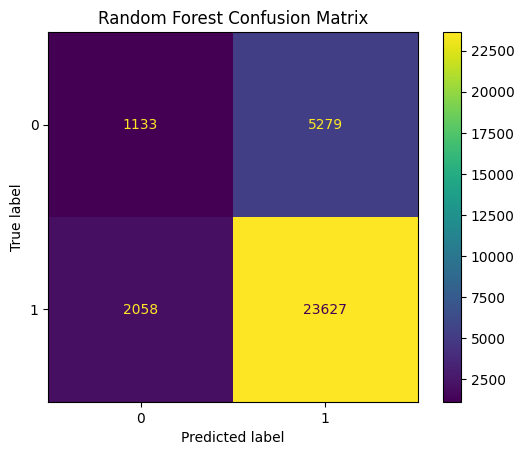

In [27]:
# Compute and plot the confusion matrix
conf_matrix = confusion_matrix(gender_pie_test, RF_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

# Scale the train and test data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


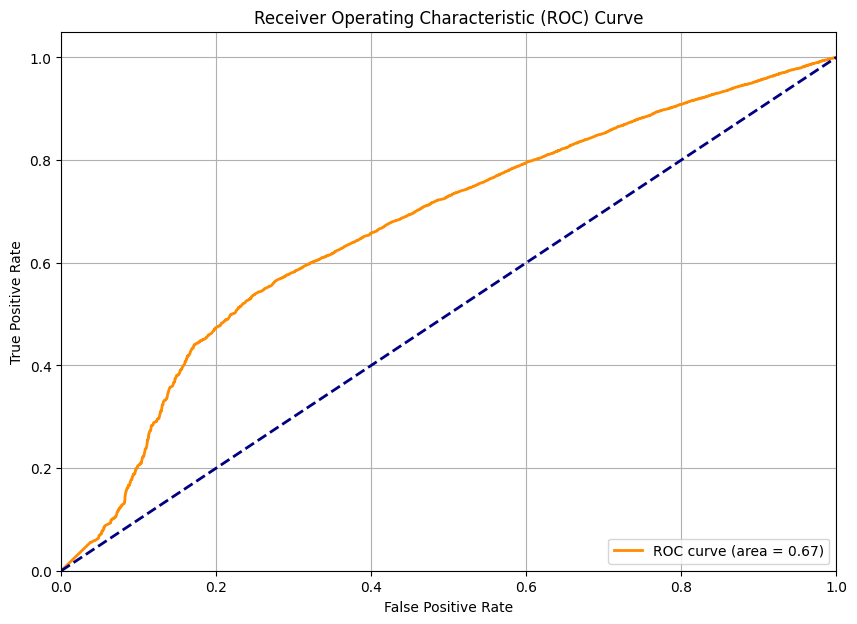

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities for ROC
gender_pie_prob = RF_model.predict_proba(x_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(gender_pie_test, gender_pie_prob)
roc_auc = roc_auc_score(gender_pie_test, gender_pie_prob)

# Plot ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


<div>
<font color='' size="5px">
The accuracy of the RF model: 78%
    </font>
</div>

..............................................................................................

<div>
<font color='grey' size="5px">
5. SVM model
    </font>
</div>

In [30]:
SVM_model = svm.SVC(kernel='rbf',gamma=0.1,C=10.0)

SVM_model.fit(x_train,gender_pie_train)

SVC(C=10.0, gamma=0.1)

In [31]:
x_test = scaler_appointment_data.fit_transform(x_test)

SVM_predict = SVM_model.predict(x_test)

In [32]:
print('Accuracy:', accuracy_score(gender_pie_test, SVM_predict))

print(classification_report(gender_pie_test, SVM_predict))

Accuracy: 0.8000747733433031
              precision    recall  f1-score   support

       False       0.41      0.00      0.00      6412
        True       0.80      1.00      0.89     25685

    accuracy                           0.80     32097
   macro avg       0.60      0.50      0.45     32097
weighted avg       0.72      0.80      0.71     32097



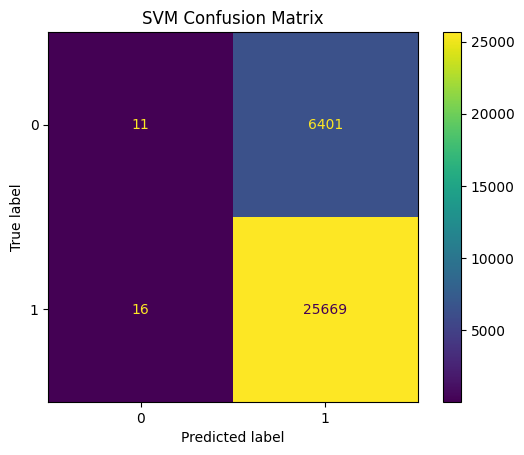

In [33]:
# Compute confusion matrix and display it
conf_matrix = confusion_matrix(gender_pie_test, SVM_predict)
confu = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

confu.plot()
plt.title("SVM Confusion Matrix")
plt.show()

<div>
<font color='grey' size="5px">
6. XGB model
    </font>
</div>

In [34]:
XGB_model = xgb.XGBClassifier()

XGB_model.fit(x_train, gender_pie_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
x_test = scaler_appointment_data.fit_transform(x_test)

XGB_predict = XGB_model.predict(x_test)

In [36]:
print('Accuracy:', accuracy_score(gender_pie_test, XGB_predict))

print(classification_report(gender_pie_test, XGB_predict))

Accuracy: 0.7959310839019222
              precision    recall  f1-score   support

       False       0.41      0.05      0.08      6412
        True       0.80      0.98      0.89     25685

    accuracy                           0.80     32097
   macro avg       0.61      0.51      0.48     32097
weighted avg       0.73      0.80      0.72     32097



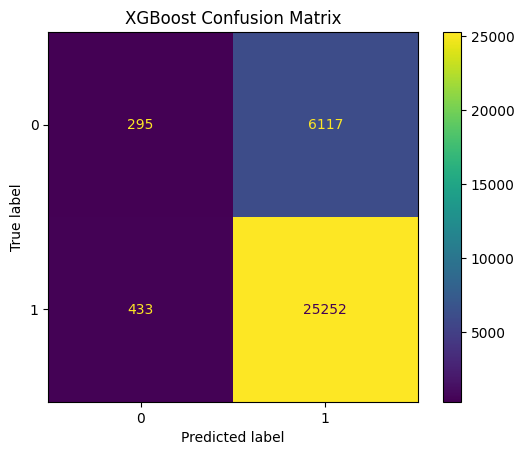

In [37]:
# Compute confusion matrix
conf_matrix = confusion_matrix(gender_pie_test, XGB_predict)

# Display confusion matrix
confu = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
confu.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

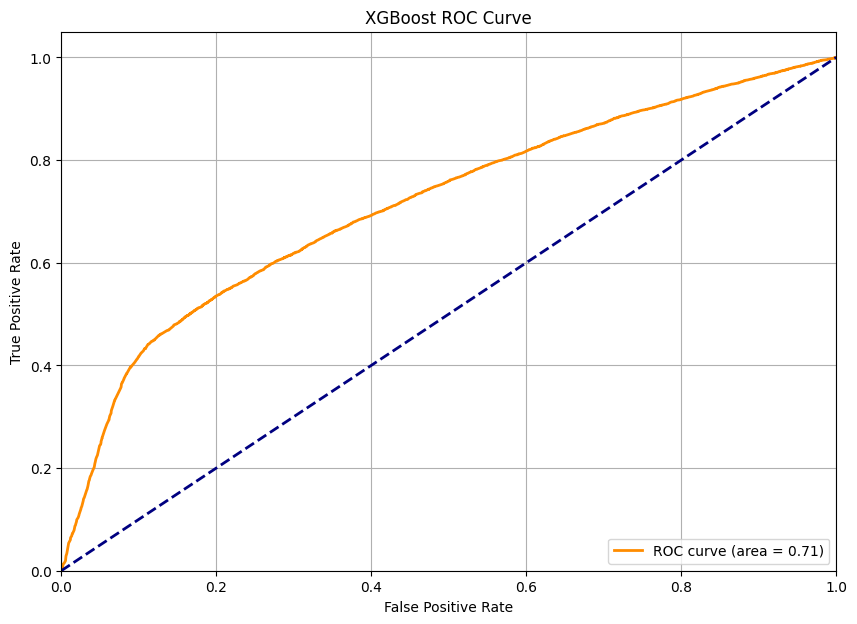

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities for class 1
gender_pie_prob = XGB_model.predict_proba(x_test_scaled)[:, 1]

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(gender_pie_test, gender_pie_prob)
roc_auc = roc_auc_score(gender_pie_test, gender_pie_prob)

# Plot ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


<div>
<font color='grey' size="5px">
7. NN model
    </font>
</div>

In [39]:
NN_model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [40]:
NN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
NN_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# 1. Compile model
NN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Train model
history = NN_model.fit(
    x_train, gender_pie_train,
    epochs=50,
    batch_size=128,
    validation_split=0.3
)


Epoch 1/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7608 - loss: 0.5462 - val_accuracy: 0.7961 - val_loss: 0.4630
Epoch 2/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7984 - loss: 0.4644 - val_accuracy: 0.7961 - val_loss: 0.4605
Epoch 3/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7986 - loss: 0.4572 - val_accuracy: 0.7961 - val_loss: 0.4551
Epoch 4/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7973 - loss: 0.4581 - val_accuracy: 0.7961 - val_loss: 0.4524
Epoch 5/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7925 - loss: 0.4613 - val_accuracy: 0.7961 - val_loss: 0.4517
Epoch 6/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7959 - loss: 0.4557 - val_accuracy: 0.7960 - val_loss: 0.4537
Epoch 7/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7982 - loss: 0.4529 - val_accuracy: 0.7961 - val_loss: 0.4516
Epoch 8/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7984 - loss: 0.4492 - val_accuracy: 0

In [43]:
print('accuracy : ',NN_model.evaluate(x_test, gender_pie_test)[1])

1004/1004 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7991 - loss: 0.4445
accuracy :  0.8004486560821533


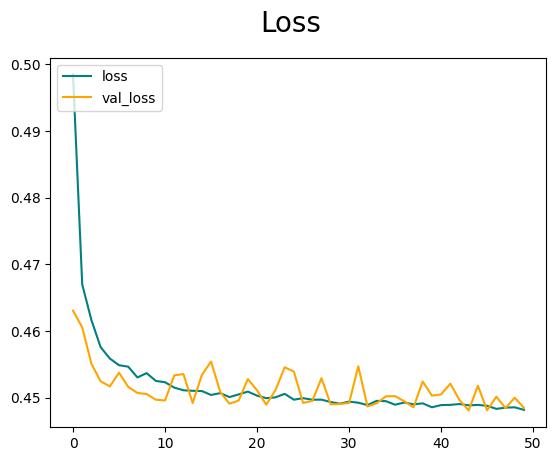

In [44]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()


**Accuracy** **Comparison**

In [45]:
svm_accuracy = accuracy_score(gender_pie_test, SVM_predict)
print("SVM Accuracy:", svm_accuracy)


SVM Accuracy: 0.8000747733433031


In [46]:
xgb_accuracy = accuracy_score(gender_pie_test, XGB_predict)
print("XGBoost Accuracy:", xgb_accuracy)


XGBoost Accuracy: 0.7959310839019222


In [47]:
nn_probs = NN_model.predict(x_test_scaled)  # Output will be probabilities
NN_predict = (nn_probs > 0.5).astype(int)   # Convert to binary class


1004/1004 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [48]:
nn_accuracy = accuracy_score(gender_pie_test, NN_predict)
print("Neural Network Accuracy:", nn_accuracy)


Neural Network Accuracy: 0.8004486400598186


In [49]:
print("Model Accuracy Comparison")
print("---------------------------")
print(f"SVM Accuracy        : {svm_accuracy:.4f}")
print(f"XGBoost Accuracy    : {xgb_accuracy:.4f}")
print(f"Neural Net Accuracy : {nn_accuracy:.4f}")


Model Accuracy Comparison
---------------------------
SVM Accuracy        : 0.8001
XGBoost Accuracy    : 0.7959
Neural Net Accuracy : 0.8004


<div>
<font color='' size="5px">
The accuracy of the SVM & XGB & NN model: 80%
    </font>
</div>